# Employee Churn Analysis and Prediction

## Project Objective

This project analyzes employee churn using HR data and machine learning. The goal is to understand the main drivers of employee attrition, identify high-risk employee segments, and build a predictive model that can support proactive retention decisions.

### Business Questions

1. Which employee characteristics are most associated with churn?
2. What patterns separate employees who stay from employees who leave?
3. Can machine learning predict churn risk accurately?
4. How can the company reduce churn through targeted retention actions?

### Methods Used

- Exploratory Data Analysis
- Churn-rate comparison
- Correlation analysis
- K-Means employee segmentation
- Logistic Regression baseline model
- Random Forest churn prediction model
- Feature importance analysis



In [27]:
#import modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

## 1. Data Loading And Overview

This section loads and inspects the HR dataset.

The dataset contains employee-level information such as satisfaction, evaluation score, workload, tenure, salary level, promotions, work accidents, department, and whether the employee left the company.

The target variable is:

| Column | Meaning |
|---|---|
| `left` | `1` = employee left, `0` = employee stayed |


In [18]:
#data loading
df = pd.read_csv("HR_comma_sep.csv")

#removing whitespace if any from columns
df.columns = df.columns.str.strip()

In [19]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [20]:
df.tail()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments,salary
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low
14998,0.37,0.52,2,158,3,0,1,0,support,low


In [36]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Departments            14999 non-null  int64  
 9   salary                 14999 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 1.1 MB


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,5.870525,1.347290
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,2.868786,0.625819
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,4.000000,1.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,7.000000,1.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,8.000000,2.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000,9.000000,2.000000


In [38]:
df["left"].value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

### Target Variable Distribution

The dataset contains **14,999 employee records** and **10 columns**. The `left` column shows that the dataset is imbalanced.

Approximately **24% of employees left the company**, while the remaining employees stayed. This means churn is a minority class, but still large enough to analyze meaningful patterns.

For business interpretation, this imbalance is important because a simple model or summary could over-focus on employees who stayed unless churned employees are analyzed separately. And also because a model could achieve reasonable accuracy by focusing mostly on employees who stayed. For this reason, recall, F1-score, and ROC-AUC are also evaluated later.

## 2. Exploratory Data Analysis

### Univariate Analysis

Univariate analysis examines one variable at a time.

This section helps answer questions such as:

- How many projects do employees usually work on?
- How long do employees typically stay with the company?
- How common are promotions?
- Which departments and salary groups have the most employees?

These distributions provide the baseline context before comparing churned and retained employees.


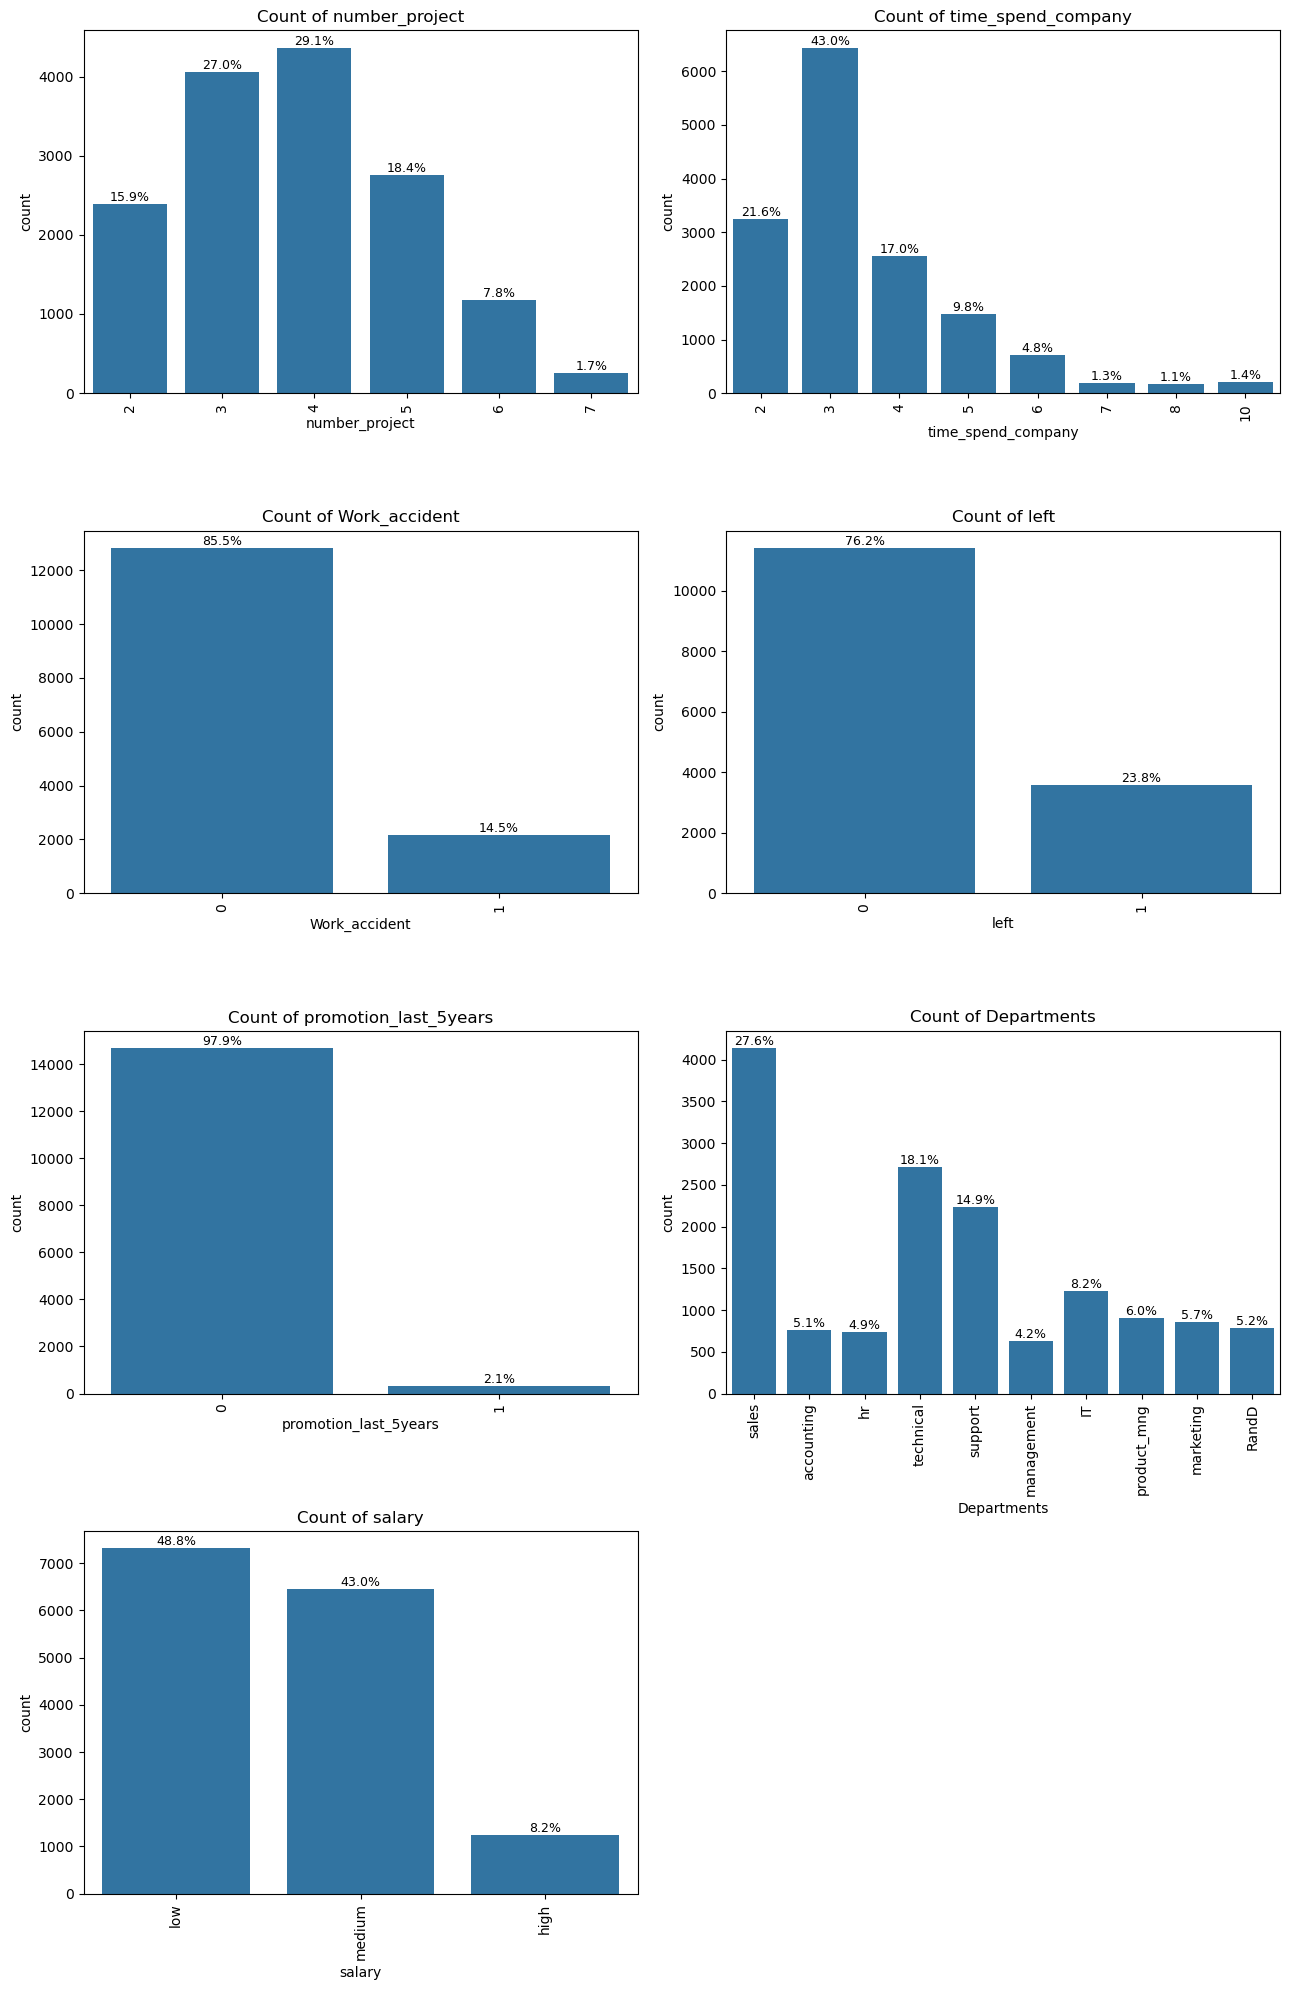

In [6]:
features = ['number_project','time_spend_company','Work_accident', 'left','promotion_last_5years','Departments','salary']

plt.figure(figsize=(13,20))

for i, j in enumerate(features):
    plt.subplot(4, 2, i+1)
    
    ax = sns.countplot(x=j, data=df)
    
    total = len(df)  # total number of rows
    
    # Add percentage labels
    for p in ax.patches:
        count = p.get_height()
        percentage = f'{100 * count / total:.1f}%'
        
        ax.annotate(
            percentage,
            (p.get_x() + p.get_width() / 2, count),  
            ha='center',
            va='bottom',
            fontsize=9
        )
    
    plt.xticks(rotation=90)
    plt.title(f"Count of {j}")
    
plt.tight_layout()
plt.show()

### Univariate Analysis — Key Findings

The main observations from the single-variable distributions are:

- Most employees work on **3 to 4 projects**, suggesting this may be the normal workload range.
- There is a noticeable drop in employee count after **3 years of tenure**, which may indicate a critical retention point.
- About **24% of employees left** the company.
- Promotions are very rare; only a small percentage of employees received a promotion in the last five years.
- The **Sales**, **Technical**, and **Support** departments contain the largest employee groups.
- Most employees fall into the **low** or **medium** salary categories.

These findings suggest that workload, tenure, salary, and promotion history may all be important churn drivers.


### Bivariate Analysis

Bivariate analysis compares each feature against the churn variable.

This section compares employee characteristics against churn. The goal is to identify early business patterns before building machine learning models. Also it helps identify how churn behavior changes across categories such as:

- number of projects
- time spent at the company
- work accident history
- promotion status
- department
- salary level

The charts display the percentage of employees who stayed and left within each category, making churn patterns easier to compare.


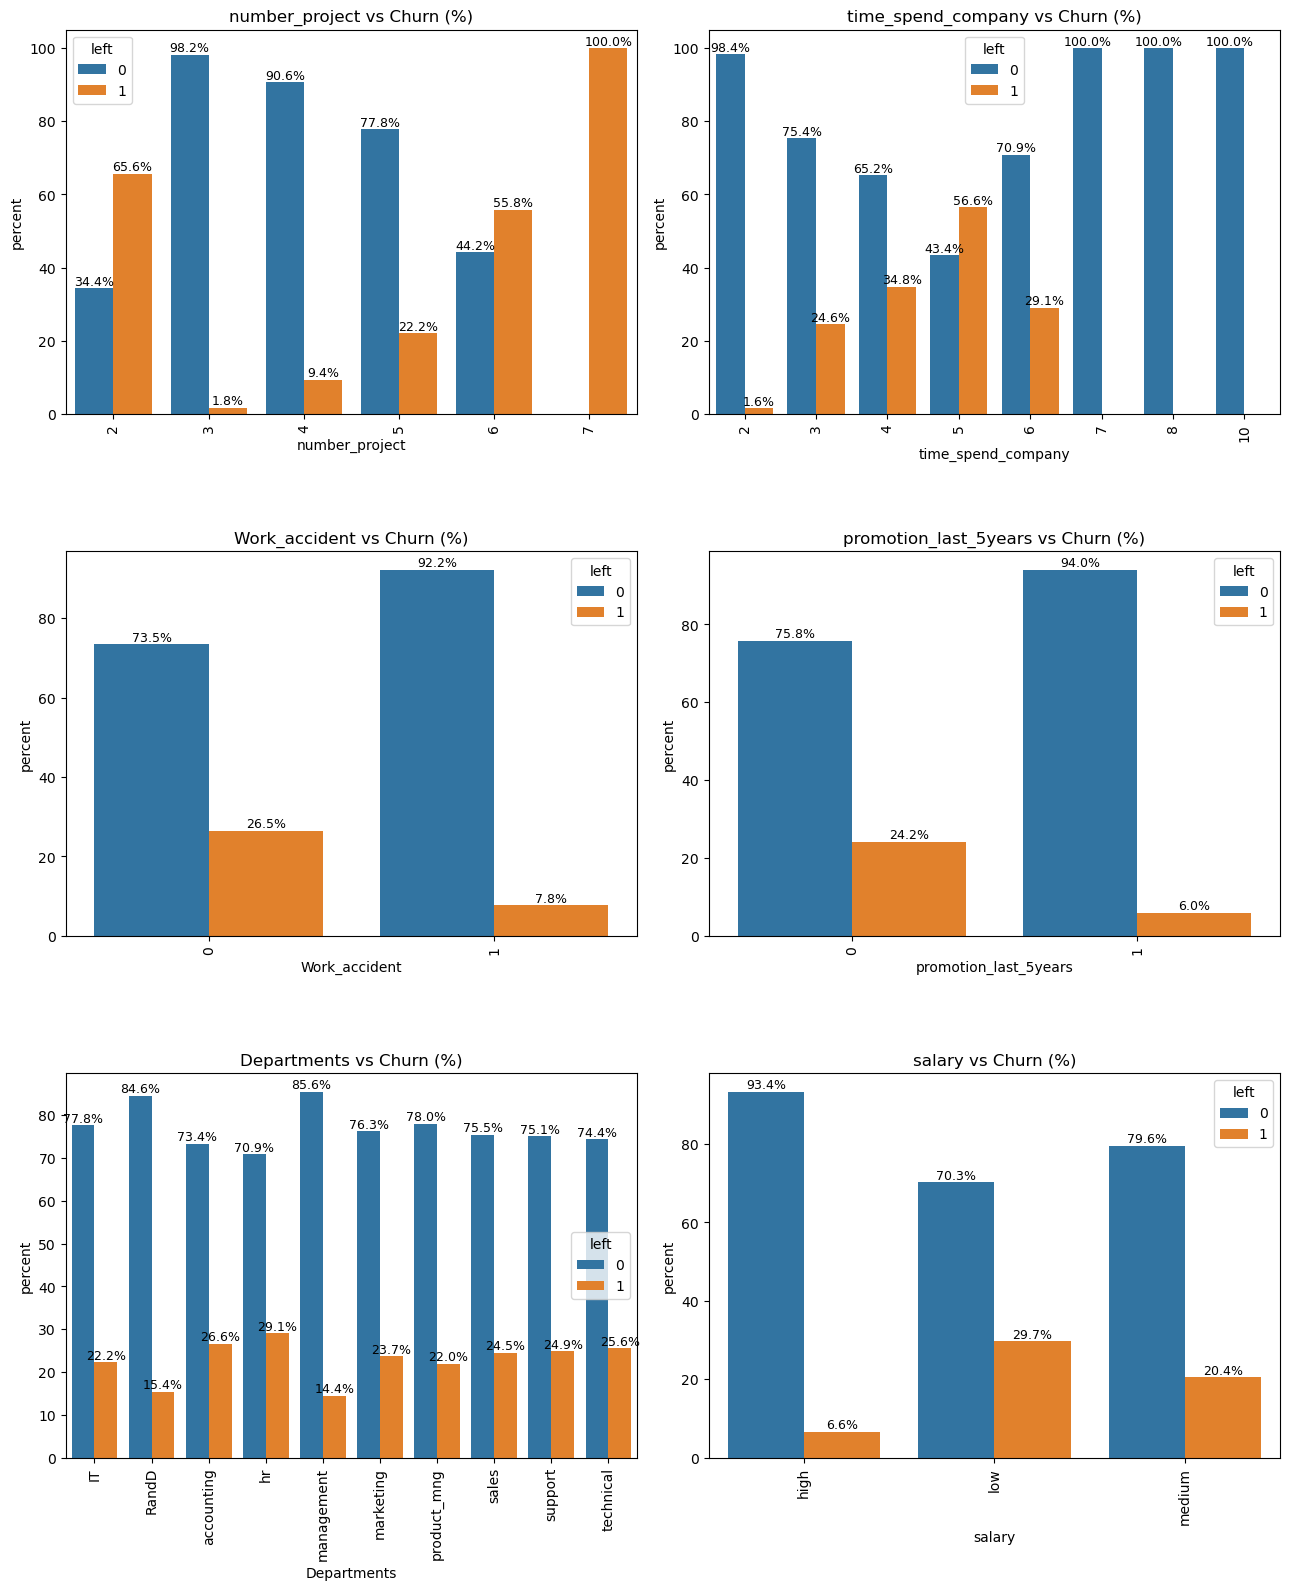

In [7]:
plt.figure(figsize=(13,20))

for i, col in enumerate(['number_project','time_spend_company','Work_accident','promotion_last_5years','Departments','salary']):
    plt.subplot(4, 2, i+1)

    # Create percentage table
    temp = df.groupby(col)['left'].value_counts(normalize=True).rename('percent').mul(100).reset_index()

    ax = sns.barplot(data=temp, x=col, y='percent', hue='left')

    # Add labels
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%',
                        (p.get_x() + p.get_width()/2, height),
                        ha='center', va='bottom', fontsize=9)

    plt.xticks(rotation=90)
    plt.title(f"{col} vs Churn (%)")

plt.tight_layout()
plt.show()

### Bivariate Analysis — Key Findings

The churn comparison reveals several important patterns:

#### Promotion and Churn

Employees who did not receive a promotion in the last five years are much more likely to leave. Although promotions are rare, they appear to be a meaningful retention factor.

#### Tenure and Churn

The **3-year mark** appears to be a critical point in the employee lifecycle. Churn is especially visible around this period, suggesting that employees may start reconsidering their career path after several years in the same organization.

#### Number of Projects

Churn follows a **U-shaped pattern**:

| Workload Level | Likely Interpretation |
|---|---|
| Too few projects | Underutilization or boredom |
| 3 to 5 projects | Healthy workload range |
| Too many projects | Burnout risk |

This suggests that both underload and overload can contribute to churn.

#### Salary

Employees in the **low** and **medium** salary groups show higher churn. This indicates that compensation may be a major retention factor, especially when combined with high workload or low promotion opportunity.

#### Department

Some departments have more churned employees than others, but this should be interpreted carefully because larger departments naturally contain more employees.


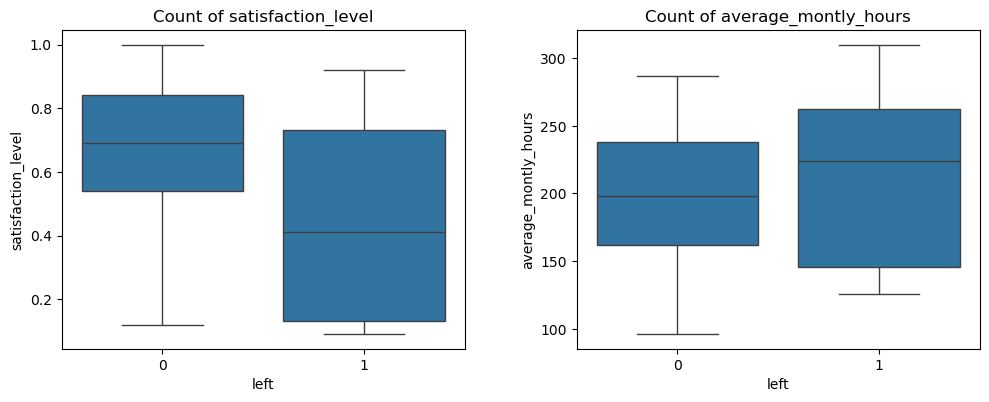

In [8]:
plt.figure(figsize=(10,15))

for i, j in enumerate(['satisfaction_level', 'average_montly_hours']):
    plt.subplot(4, 2, i+1)
    sns.boxplot(x='left', y=j, data=df)
    plt.title(f"Count of {j}")

plt.tight_layout(w_pad = 4.0)
plt.show()

### Boxplot Insights: Satisfaction and Monthly Hours

The boxplots compare employees who stayed versus employees who left.

Key observations:

- Employees who left generally have **lower satisfaction levels**.
- Employees who left also tend to show **higher monthly working hours**.
- This combination suggests that churn is strongly related to both emotional dissatisfaction and workload pressure.

In business terms, employees are most at risk when they are both unhappy and overworked.


## 3. Initial Business Recommendations

Based on the exploratory analysis, the company should prioritize the following actions:

| Problem Area | Recommended Action |
|---|---|
| Low satisfaction | Run regular feedback surveys and manager check-ins |
| Rare promotions | Create transparent promotion criteria and career paths |
| High workload | Monitor monthly hours and limit excessive project assignments |
| Low salary groups | Review compensation fairness, especially for high performers |
| Tenure risk | Create retention programs around the 3-year employee milestone |

These actions directly address the strongest churn patterns found in the exploratory analysis.


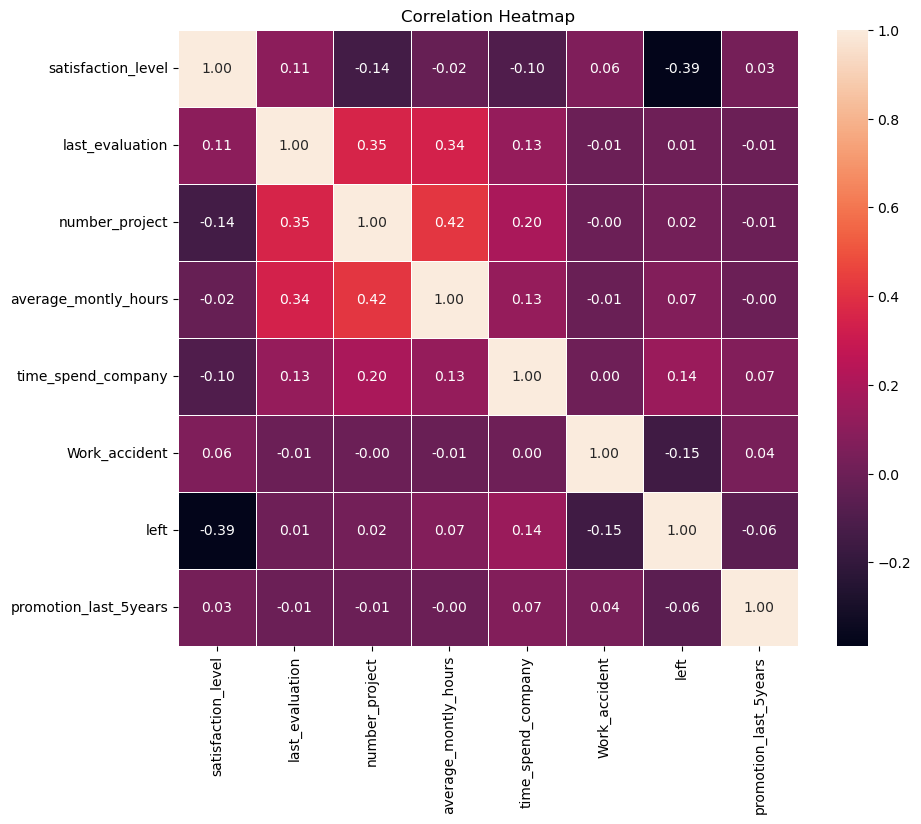

In [9]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,        # adds numbers
    fmt=".2f",         # 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap — Key Insights

The correlation heatmap shows relationships between numerical variables.

Important findings:

#### Satisfaction vs. Churn

`Satisfaction Level` has a strong negative relationship with churn. As satisfaction decreases, the probability of an employee leaving increases.

This is one of the most important churn signals in the dataset.

#### Projects and Monthly Hours

`Number of Projects` and `Average Monthly Hours` are positively related. Employees with more projects tend to work more hours, which can create burnout risk.

#### Tenure and Churn

`Time Spent Company` has a weaker but still meaningful relationship with churn. Employees around the mid-tenure range appear to be more vulnerable to leaving.

#### Promotion and Churn

Promotion has a weak negative correlation with churn, but this does not mean it is unimportant. Because promotions are rare, their effect may not appear strongly in simple correlation, but they can still be very meaningful from a business perspective.


## 4. Overall Churn Pattern

The analysis suggests that employee churn is influenced by a combination of satisfaction, workload, compensation, and career growth.

| Churn Driver | Business Interpretation |
|---|---|
| Low satisfaction | Emotional dissatisfaction |
| Low salary | Compensation dissatisfaction |
| No promotion | Career stagnation |
| Too many projects | Burnout |
| Too few projects | Low engagement or underutilization |

A simple way to summarize the pattern is:

> **Churn = Satisfaction + Workload + Career Growth + Compensation**

### Strategic Business Solutions

1. **Optimize workload**
   - Keep most employees within a healthy range of 3 to 5 projects.
   - Monitor employees with fewer than 3 projects or more than 5 projects.

2. **Improve promotion and career mobility**
   - Build clear promotion criteria.
   - Offer internal mobility opportunities.
   - Identify high performers who may feel stuck.

3. **Review salary fairness**
   - Focus on low-salary employees with high workload or high performance.
   - Compare compensation against role expectations and market standards.

4. **Build an early warning system**
   - Flag employees with low satisfaction, high workload, long tenure, or no recent promotion.


## 5. Cluster Analysis

Clustering is used to group employees into behavior-based segments.

Unlike a supervised prediction model, clustering does not directly predict churn. Instead, it helps identify different types of employees based on similar patterns.

For this analysis, the clustering features are:

| Feature | Reason for Inclusion |
|---|---|
| `satisfaction_level` | Measures employee engagement and happiness |
| `last_evaluation` | Captures recent performance |
| `number_project` | Represents workload volume |
| `average_montly_hours` | Measures work intensity |
| `time_spend_company` | Captures tenure and employee lifecycle stage |

The goal is to understand what kinds of employee profiles are associated with higher churn risk.

The data is scaled before clustering because K-Means is distance-based. Scaling prevents variables with larger numeric ranges, such as monthly hours, from dominating the clustering process.

After clustering, the analysis focuses specifically on employees who left the company. This makes the plots more useful because they show the behavior patterns among churned employees rather than mixing churned and retained employees together.


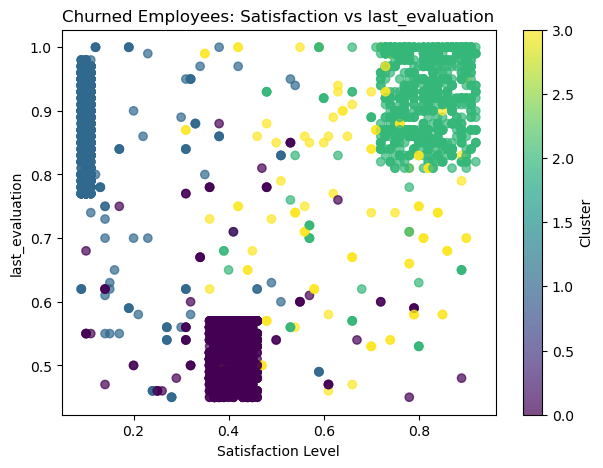

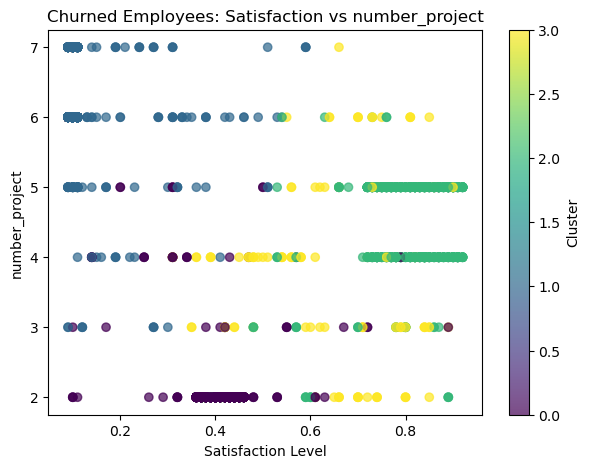

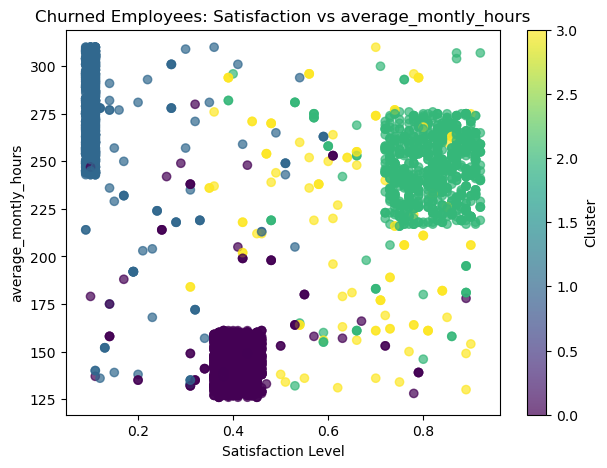

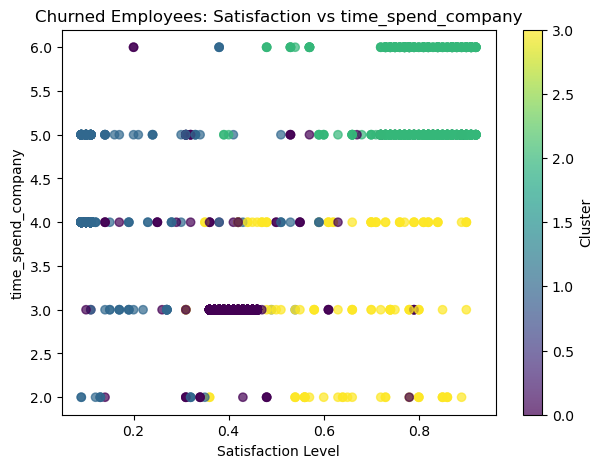

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,left,churn_rate_percent
cluster,,,,,,,
1,0.173199,0.807311,5.641457,247.961905,4.256022,0.541176,54.117647
2,0.753583,0.822191,4.204050,222.177051,6.178609,0.470405,47.040498
0,0.479275,0.546210,2.722222,153.134585,3.143192,0.412102,41.210224
3,0.750441,0.754233,3.815133,209.003354,2.806815,0.015965,1.596458


In [41]:
Cluster_Features = [
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_montly_hours',
    'time_spend_company'
]

X = df[Cluster_Features]

# Scale data because K-Means is distance-based
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clustered = df.copy()
df_clustered['cluster'] = kmeans.fit_predict(X_scaled)

# Filter only employees who left
left_df = df_clustered[df_clustered['left'] == 1]

# Visualize churned employees only
plot_features = [
    'last_evaluation',
    'number_project',
    'average_montly_hours',
    'time_spend_company'
]

for feature in plot_features:
    plt.figure(figsize=(7, 5))
    plt.scatter(
        left_df['satisfaction_level'],
        left_df[feature],
        c=left_df['cluster'],
        alpha=0.7
    )
    plt.xlabel("Satisfaction Level")
    plt.ylabel(feature)
    plt.title(f"Churned Employees: Satisfaction vs {feature}")
    plt.colorbar(label="Cluster")
    plt.show()

# Cluster summary
summary = df_clustered.groupby('cluster')[Cluster_Features + ['left']].mean()
summary['churn_rate_percent'] = summary['left'] * 100

summary.sort_values('churn_rate_percent', ascending=False)

### Cluster Interpretation and Churn Profiles

The cluster summary shows that employee churn is not caused by one single issue. Instead, there are multiple churn profiles.

#### Cluster 1 — Extreme Burnout Employees

This group has the highest churn risk.

Typical characteristics:

- Very low satisfaction
- Very high monthly hours
- Many projects
- Strong workload pressure

Business interpretation:

> These employees are likely leaving because of burnout.

They may be productive and heavily utilized, but the combination of low satisfaction and excessive workload makes them highly vulnerable to resignation.

Recommended prevention actions:

- Reduce excessive project load.
- Monitor overtime.
- Improve manager check-ins.
- Recognize and reward high workload contributors.
- Rebalance work across teams.

---

#### Cluster 0 — Disengaged Moderate-Workload Employees

This group shows moderate-to-high churn risk but does not appear to be overworked.

Typical characteristics:

- Lower satisfaction
- Fewer projects
- Lower monthly hours
- Moderate tenure

Business interpretation:

> These employees may be under-engaged or disconnected from their work.

They may not be leaving because of burnout. Instead, they may feel underutilized, unmotivated, or disconnected from growth opportunities.

Recommended prevention actions:

- Increase meaningful project ownership.
- Provide mentoring or coaching.
- Improve role clarity.
- Offer internal mobility opportunities.
- Conduct engagement interviews.

---

#### Cluster 2 — High-Performing Long-Tenure Risk Employees

This is one of the most important business segments.

Typical characteristics:

- High satisfaction
- High evaluation scores
- Longer tenure
- High workload

Business interpretation:

> These employees may be leaving because of career plateauing or better external opportunities.

Even satisfied employees can leave when they feel they have reached a salary, promotion, or growth ceiling.

Recommended prevention actions:

- Create leadership development tracks.
- Review compensation for long-tenure high performers.
- Offer promotion or internal mobility pathways.
- Assign strategic projects.
- Conduct stay interviews before they begin job searching.

---

#### Cluster 3 — Stable Loyal Employees

This group has the lowest churn risk.

Typical characteristics:

- High satisfaction
- Balanced workload
- Shorter tenure
- Moderate number of projects

Business interpretation:

> This group represents the healthiest employee profile in the organization.

These employees appear engaged, productive, and less likely to leave.

Recommended prevention actions:

- Study this group as a retention benchmark.
- Identify what management practices are working for them.
- Replicate these conditions across higher-risk teams.

---

### Final Cluster Summary

| Churn Profile | Likely Cause | Recommended HR Response |
|---|---|---|
| Burnout churn | Overwork and low satisfaction | Reduce workload and improve support |
| Disengagement churn | Low motivation or underutilization | Improve engagement and role fit |
| Career mobility churn | Growth or compensation ceiling | Offer advancement and retention plans |
| Stable employees | Balanced work and high satisfaction | Preserve and replicate conditions |

### Key Business Takeaway

Employee churn is not one problem. The company needs different retention strategies for different employee groups.

A single retention policy will not work for everyone. The most effective approach is segment-specific retention planning.


## 6. Machine Learning Churn Prediction

This section builds supervised classification models to predict whether an employee is likely to leave.

Two models are used:

1. **Logistic Regression** — interpretable baseline model.
2. **Random Forest** — non-linear model that can capture more complex churn patterns.

Important modeling decision: the clustering label is not used as a feature in the supervised model. The model is trained only on original employee attributes to avoid confusing the segmentation output with prediction inputs.

                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  Logistic Regression  0.757667   0.469208  0.226629  0.305635  0.573864
1        Random Forest  0.988333   0.986938  0.963173  0.974910  0.979625


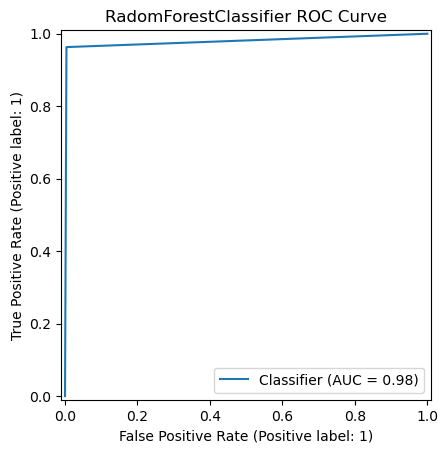

In [46]:
#Encoding Categorical Variable
le = LabelEncoder()
df['salary'] = le.fit_transform(df['salary'])
df['Departments'] = le.fit_transform(df['Departments'])

#Data preparation
X = df.drop('left', axis=1)
y = df['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

#Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

#Evaluation
def evaluate(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_pred)
    }

#LogisticRegression Metric
lr_metrics = evaluate(y_test, y_pred_lr)
#RandomForestClassifier Metric
rf_metrics = evaluate(y_test, y_pred_rf)

#DataFrame for metrics
df_metrics = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_metrics["Accuracy"], rf_metrics["Accuracy"]],
    "Precision": [lr_metrics["Precision"], rf_metrics["Precision"]],
    "Recall": [lr_metrics["Recall"], rf_metrics["Recall"]],
    "F1": [lr_metrics["F1"], rf_metrics["F1"]],
    "ROC_AUC": [lr_metrics["ROC_AUC"], rf_metrics["ROC_AUC"]]
})

print(df_metrics)

#ROC curve
RocCurveDisplay.from_predictions(y_test, y_pred_rf)
plt.title("RadomForestClassifier ROC Curve")
plt.show()

**Model Interpretation**
- *Logistic Regression*
    - Weak at detecting wmployees who leave
    - Misses many churn cases (low Recall)

- *Random Forest*
    - Near-perfect model performance
    - Captures almost all employees who leave
    - Very low false predictions

The Random Forest model performs better than Logistic Regression across key classification metrics. For churn prediction, recall is especially important because missing high-risk employees can prevent HR from intervening early.

- The Random Forest model achieved a ROC-AUC score of 0.98, indicating excellent capability in distinguishing employees likely to churn from those likely to remain with the company.

**Confusion Matrix**

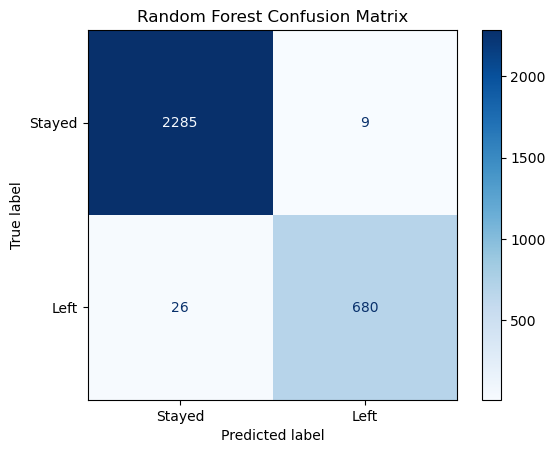

In [26]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

**Insights**
- Only 26 missed churn cases
- Only 9 false alarms

## 7. Feature Importance

Feature importance helps explain which variables contributed most to the Random Forest model's predictions.

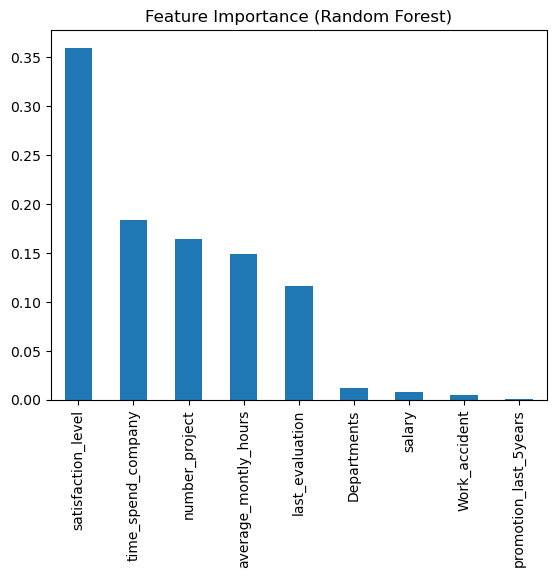

In [14]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure()
importances.plot(kind='bar')
plt.title('Feature Importance (Random Forest)')
plt.xticks(rotation=90)
plt.show()

### Feature Importance Interpretation

The strongest churn drivers are typically:

1. Satisfaction level
2. Time spent at the company
3. Number of projects
4. Average monthly hours
5. Last evaluation score

This confirms the earlier EDA and clustering insights. Employees leave due to a mix of satisfaction, workload, tenure stage, and performance context.

**CRITICAL BUSINESS INSIGHTS (VERY IMPORTANT)**
1. Satisfaction is the KING VARIABLE\
Biggest predictor by far\
Employees don’t leave because of data… they leave because of feelings

2. Experience (Tenure) is a Major Factor\
Employees leave after certain years -> Mid-career churn problem

3. Workload Drives Churn\
Projects + hours combined are powerful\
Confirms earlier EDA:\
Overwork = churn\
Underwork = churn

4. Salary & Promotion Appear Less Important (BUT CAREFUL)\
This does NOT mean they don’t matter
*Why low importance?*
They are:\
Rare (promotion)\
Categorical (less variance)\
BUT: They still influence satisfaction indirectly

**FINAL CHURN MODEL EQUATION (SIMPLIFIED)**\
Churn ≈ f (Satisfaction + Workload + Experience + Performance)

**ACTIONABLE BUSINESS STRATEGY (DATA-DRIVEN)**
1. Build Early Warning System\
Use model to flag employees with:\
Low satisfaction\
High workload\
3–5 years tenure

2. Optimize Workload Distribution\
Keep projects between 3–4\
Monitor employees:\
5 projects\
<3 projects

3. Satisfaction Intervention System\
Monthly surveys\
Manager check-ins

4. Retain High-Risk Employees
Focus on:\
High performers with low satisfaction

5. Predict & Prevent Churn
Use model to:\
Score employees\
Intervene early

## 8. Business Recommendations

Based on the analysis, HR should focus on targeted churn prevention rather than using one retention strategy for all employees.

| Risk Pattern | Prevention Action |
|---|---|
| Low satisfaction | Regular pulse surveys, manager check-ins, engagement plans |
| High workload | Project-load monitoring, overtime controls, workload redistribution |
| Too few projects | Better role design, internal mobility, skill development |
| Mid-tenure risk | Career-path reviews around 3 to 5 years |
| High performers at risk | Stay interviews, growth opportunities, compensation review |

### Final Conclusion

Employee churn is driven by multiple factors. The strongest signals are satisfaction, tenure, project load, monthly hours, and evaluation score. The Random Forest model can help identify likely churn cases, while clustering explains different types of churn behavior.

The most practical business outcome is an early-warning retention system that flags employees who may need manager attention before they resign.